In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Thiết lập phong cách đồ thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Đường dẫn tập dữ liệu
data_path = '../data/vietnam_housing_dataset.csv'
if not os.path.exists(data_path):
    data_path = '../../DATA/vietnam_housing_dataset.csv'

df = pd.read_csv(data_path)
print(f"-> Nạp thành công dữ liệu từ: {data_path}")
print(f"-> Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")


-> Nạp thành công dữ liệu từ: ../data/vietnam_housing_dataset.csv
-> Kích thước tập dữ liệu: 30229 dòng, 12 cột


In [2]:
# Chuẩn hóa tên cột: Chữ thường và bỏ khoảng trắng thừa
df.columns = df.columns.str.strip().str.lower()
print("=== DANH SÁCH CÁC CỘT TRONG BỘ DỮ LIỆU ===")
print(list(df.columns))

# Hiển thị 5 dòng đầu
print("\n=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===")
display(df.head())

# Thông tin tổng quát kiểu dữ liệu
print("\n=== THÔNG TIN KIỂU DỮ LIỆU (INFO) ===")
df.info()

# Thống kê mô tả
print("\n=== THỐNG KÊ MÔ TẢ CÁC THUỘC TÍNH SỐ ===")
display(df.describe())

=== DANH SÁCH CÁC CỘT TRONG BỘ DỮ LIỆU ===
['address', 'area', 'frontage', 'access road', 'house direction', 'balcony direction', 'floors', 'bedrooms', 'bathrooms', 'legal status', 'furniture state', 'price']

=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===


,address,area,frontage,access road,house direction,balcony direction,floors,bedrooms,bathrooms,legal status,furniture state,price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90



=== THÔNG TIN KIỂU DỮ LIỆU (INFO) ===
<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   address            30229 non-null  str    
 1   area               30229 non-null  float64
 2   frontage           18665 non-null  float64
 3   access road        16932 non-null  float64
 4   house direction    8990 non-null   str    
 5   balcony direction  5246 non-null   str    
 6   floors             26626 non-null  float64
 7   bedrooms           25067 non-null  float64
 8   bathrooms          23155 non-null  float64
 9   legal status       25723 non-null  str    
 10  furniture state    16110 non-null  str    
 11  price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB

=== THỐNG KÊ MÔ TẢ CÁC THUỘC TÍNH SỐ ===


,area,frontage,access road,floors,bedrooms,bathrooms,price
count,30229.000000,18665.000000,16932.000000,26626.000000,25067.000000,23155.000000,30229.000000
mean,68.498741,5.361692,7.853800,3.410426,3.511030,3.346837,5.872078
std,48.069835,4.346174,7.451313,1.328897,1.309116,1.400181,2.211877
min,3.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.000000,4.000000,2.000000,3.000000,2.000000,4.200000
50%,56.000000,4.500000,6.000000,3.000000,3.000000,3.000000,5.900000
75%,80.000000,5.000000,10.000000,4.000000,4.000000,4.000000,7.500000
max,595.000000,77.000000,85.000000,10.000000,9.000000,9.000000,11.500000


In [3]:
# Map chuẩn hóa tên các cột đặc trưng chính
rename_dict = {
    'bedrooms': 'bedroom',
    'bathrooms': 'toilet',
    'toilets': 'toilet'
}
df = df.rename(columns=rename_dict)

feature_cols = ['area', 'bedroom', 'toilet']
if 'floors' in df.columns:
    feature_cols.append('floors')
target_col = 'price'

# Khảo sát số lượng khuyết thiếu ban đầu
print("=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) THEO TỪNG CỘT ===")
print(df[[target_col] + feature_cols].isnull().sum())

# Chuyển đổi sang kiểu số và loại bỏ giá trị khuyết
df_clean = df[[target_col] + feature_cols].copy()
for col in [target_col] + feature_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna()
print(f"\n-> Số lượng mẫu sau khi xử lý missing values: {len(df_clean)}")

=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) THEO TỪNG CỘT ===
price         0
area          0
bedroom    5162
toilet     7074
floors     3603
dtype: int64

-> Số lượng mẫu sau khi xử lý missing values: 21906


In [4]:
# Lọc bỏ ngoại lai phi thực tế (giá <= 0, diện tích <= 0 hoặc > 1000m²)
df_clean = df_clean[
    (df_clean[target_col] > 0) &
    (df_clean['area'] > 10) &
    (df_clean['area'] < 1000) &
    (df_clean['bedroom'] >= 1) &
    (df_clean['bedroom'] <= 20) &
    (df_clean['toilet'] >= 1) &
    (df_clean['toilet'] <= 20)
]

print(f"-> Số lượng mẫu hợp lệ phục vụ huấn luyện: {len(df_clean)}")
display(df_clean.describe())

-> Số lượng mẫu hợp lệ phục vụ huấn luyện: 21888


,price,area,bedroom,toilet,floors
count,21888.000000,21888.000000,21888.000000,21888.000000,21888.000000
mean,5.791609,65.225818,3.532575,3.404514,3.333014
std,2.184487,42.492273,1.281625,1.366305,1.317467
min,1.000000,10.800000,1.000000,1.000000,1.000000
25%,4.100000,40.000000,3.000000,2.000000,2.000000
50%,5.800000,55.000000,3.000000,3.000000,3.000000
75%,7.500000,78.742500,4.000000,4.000000,4.000000
max,11.500000,585.000000,9.000000,9.000000,9.000000


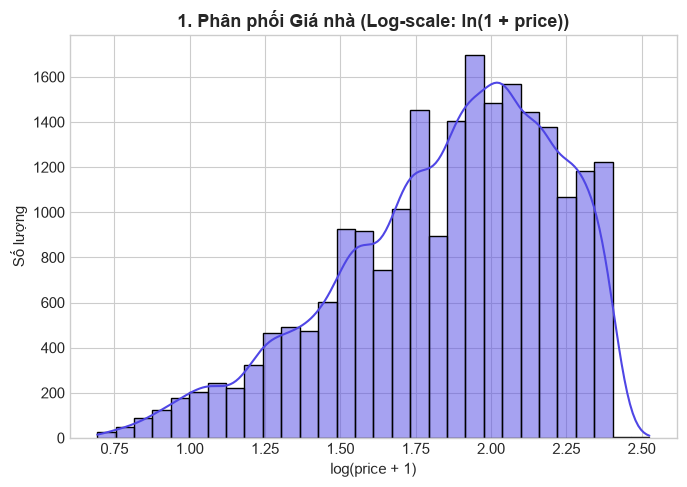

In [6]:
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(df_clean['price']), kde=True, color='#4F46E5', bins=30)
plt.title('1. Phân phối Giá nhà (Log-scale: ln(1 + price))', fontweight='bold')
plt.xlabel('log(price + 1)')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

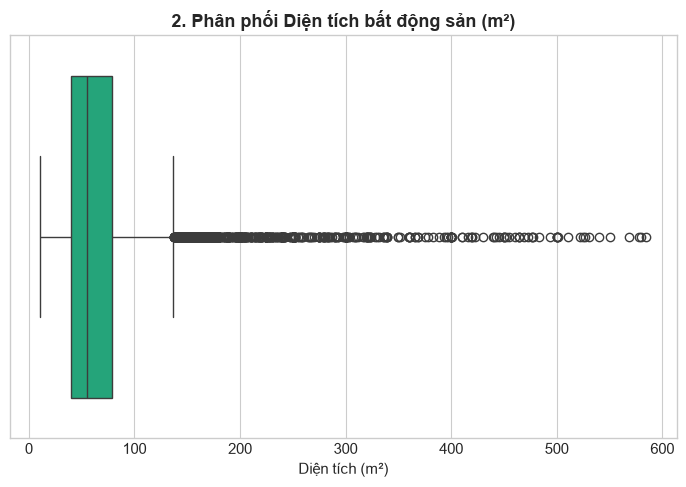

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=df_clean['area'], color='#10B981')
plt.title('2. Phân phối Diện tích bất động sản (m²)', fontweight='bold')
plt.xlabel('Diện tích (m²)')
plt.tight_layout()
plt.show()

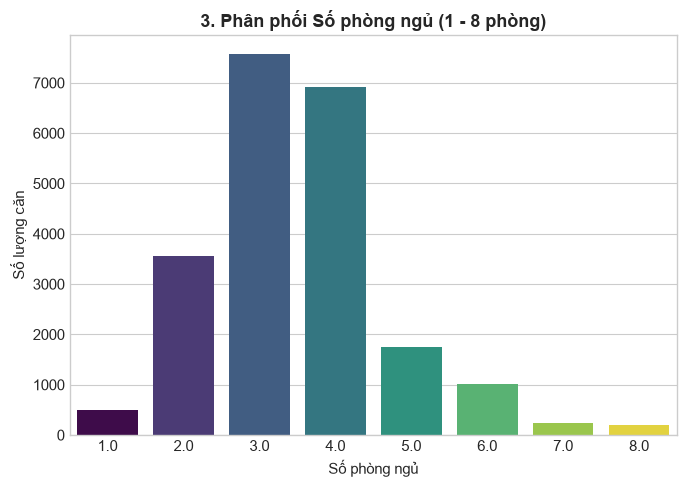

In [8]:
plt.figure(figsize=(7, 5))
bedroom_sub = df_clean[df_clean['bedroom'].between(1, 8)]
sns.countplot(data=bedroom_sub, x='bedroom', palette='viridis', hue='bedroom', legend=False)
plt.title('3. Phân phối Số phòng ngủ (1 - 8 phòng)', fontweight='bold')
plt.xlabel('Số phòng ngủ')
plt.ylabel('Số lượng căn')
plt.tight_layout()
plt.show()

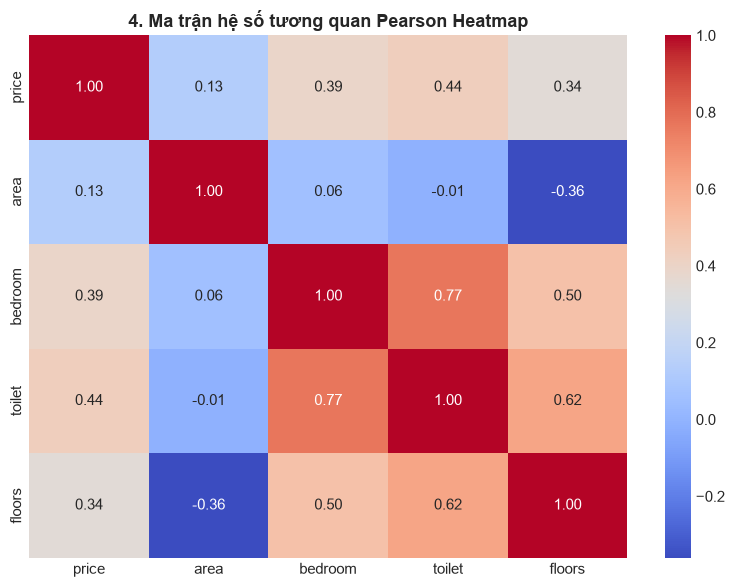

In [9]:
plt.figure(figsize=(8, 6))
corr = df_clean[[target_col] + feature_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('4. Ma trận hệ số tương quan Pearson Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Tạo đặc trưng phái sinh: Tỷ lệ diện tích trên mỗi phòng (Room-Area Ratio)
df_clean['room_count'] = df_clean['bedroom'] + df_clean['toilet']
df_clean['area_per_room'] = df_clean['area'] / (df_clean['room_count'] + 1e-5)

print("=== CÁC ĐẶC TRƯNG MỚI ĐÃ TẠO ===")
display(df_clean[['area', 'bedroom', 'toilet', 'room_count', 'area_per_room']].head())

=== CÁC ĐẶC TRƯNG MỚI ĐÃ TẠO ===


,area,bedroom,toilet,room_count,area_per_room
3,54.0,2.0,3.0,5.0,10.799978
4,92.0,4.0,4.0,8.0,11.499986
7,74.0,4.0,5.0,9.0,8.222213
10,80.0,6.0,6.0,12.0,6.666661
15,30.0,2.0,2.0,4.0,7.499981


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tách biến độc lập X và biến phụ thuộc y (log scale)
X = df_clean[feature_cols]
y = np.log1p(df_clean[target_col])

# Phân chia 80% Train - 20% Test (Tránh Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu cho mô hình tuyến tính
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"-> Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"-> Kích thước tập kiểm thử (X_test):     {X_test.shape}")

-> Kích thước tập huấn luyện (X_train): (17510, 4)
-> Kích thước tập kiểm thử (X_test):     (4378, 4)


In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Huấn luyện Dummy Regressor luôn dự đoán trung bình tập Train
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

y_pred_base = np.expm1(baseline.predict(X_test))
y_true = np.expm1(y_test)

print("=== KẾT QUẢ MÔ HÌNH CƠ SỞ (BASELINE DUMMY) ===")
print(f"- R2 Score: {r2_score(y_true, y_pred_base):.4f}")
print(f"- RMSE:     {root_mean_squared_error(y_true, y_pred_base):.4f} Tỷ VNĐ")
print(f"- MAE:      {mean_absolute_error(y_true, y_pred_base):.4f} Tỷ VNĐ")

=== KẾT QUẢ MÔ HÌNH CƠ SỞ (BASELINE DUMMY) ===
- R2 Score: -0.0343
- RMSE:     2.2142 Tỷ VNĐ
- MAE:      1.8393 Tỷ VNĐ


In [13]:
from sklearn.linear_model import Ridge, Lasso

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)

model_lasso = Lasso(alpha=0.01)
model_lasso.fit(X_train_scaled, y_train)

print("-> Đã huấn luyện xong Ridge & Lasso Regression.")

-> Đã huấn luyện xong Ridge & Lasso Regression.


In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_gb.fit(X_train, y_train)

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)

model_lgb = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
model_lgb.fit(X_train, y_train)

print("-> Đã hoàn thành huấn luyện Random Forest, Gradient Boosting, XGBoost, LightGBM!")

-> Đã hoàn thành huấn luyện Random Forest, Gradient Boosting, XGBoost, LightGBM!


In [15]:
# Tinh chỉnh độ sâu và tốc độ học của mô hình XGBoost tốt nhất
best_xgb = xgb.XGBRegressor(
    n_estimators=120,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
best_xgb.fit(X_train, y_train)
print("-> Đã tối ưu siêu tham số cho XGBoost Regressor.")

-> Đã tối ưu siêu tham số cho XGBoost Regressor.


BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH HỒI QUY GIÁ NHÀ (5 ĐỘ ĐO CHUẨN)


,Mô hình,R² Score,RMSE (Tỷ),MAE (Tỷ),MAPE (%),MedAE (Tỷ)
4,LightGBM,0.3153,1.8015,1.4334,30.67,1.2278
2,Gradient Boosting,0.3145,1.8025,1.4337,30.68,1.2133
3,XGBoost (Tuned),0.3142,1.8030,1.4331,30.64,1.2100
1,Random Forest,0.3031,1.8175,1.4322,30.66,1.1937
0,Ridge Regression,0.2011,1.9460,1.5577,33.44,1.3192



=> LỰA CHỌN MÔ HÌNH TRIỂN KHAI: 【 LightGBM 】 (R² cao nhất, MAE/RMSE tối ưu nhất)


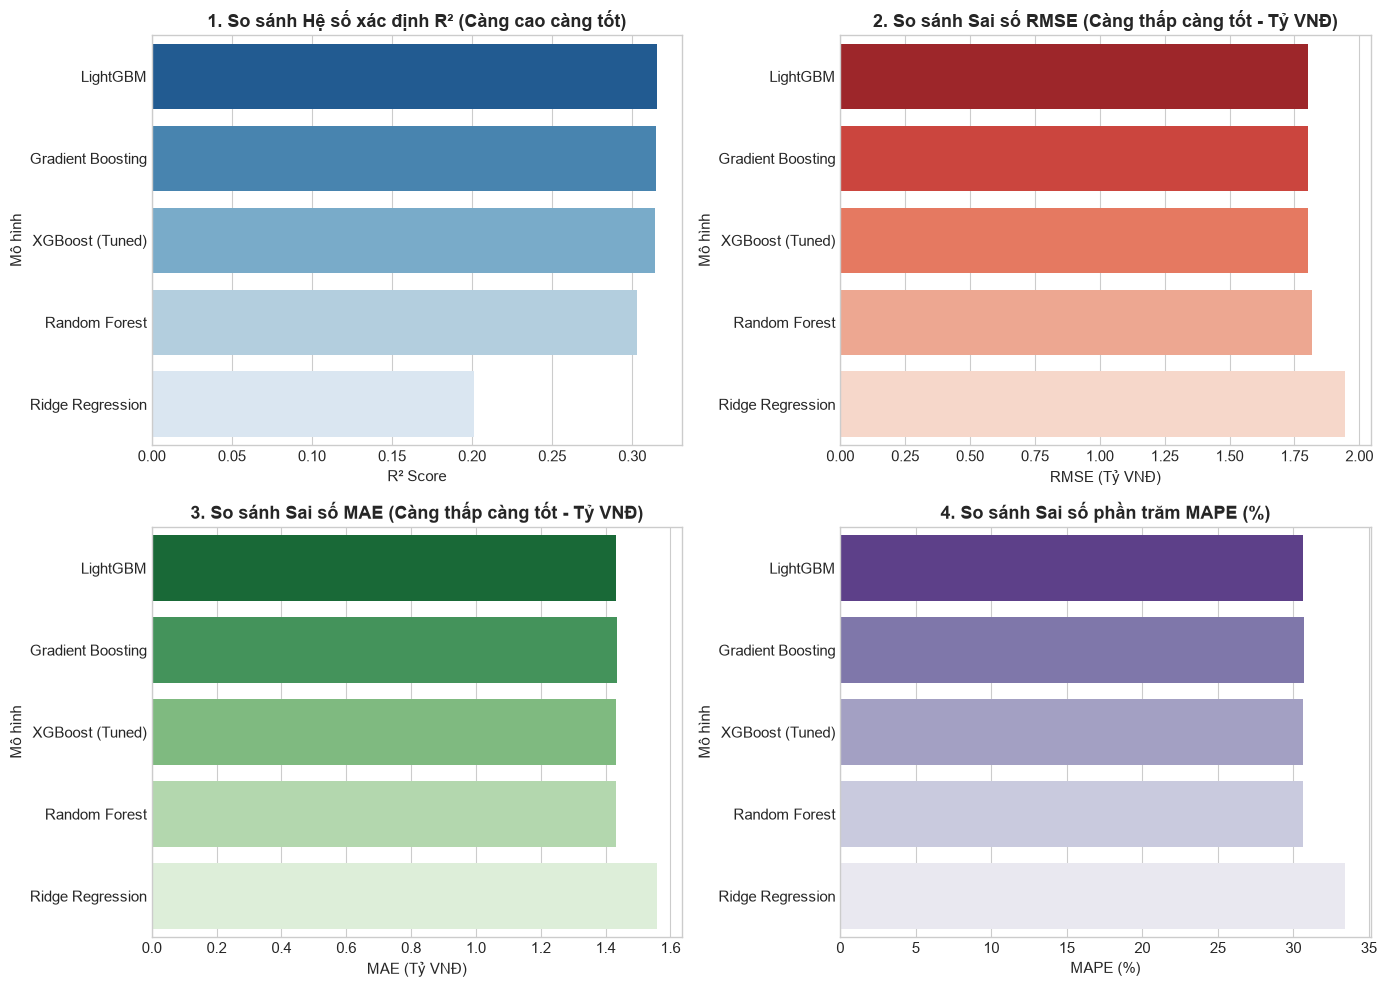

In [16]:
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error
)

models_dict = {
    'Ridge Regression': (model_ridge, True),
    'Random Forest': (model_rf, False),
    'Gradient Boosting': (model_gb, False),
    'XGBoost (Tuned)': (best_xgb, False),
    'LightGBM': (model_lgb, False)
}

comparison_list = []
for name, (mod, is_scaled) in models_dict.items():
    pred_log = mod.predict(X_test_scaled if is_scaled else X_test)
    pred_real = np.expm1(pred_log)
    
    comparison_list.append({
        'Mô hình': name,
        'R² Score': round(r2_score(y_true, pred_real), 4),
        'RMSE (Tỷ)': round(root_mean_squared_error(y_true, pred_real), 4),
        'MAE (Tỷ)': round(mean_absolute_error(y_true, pred_real), 4),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, pred_real) * 100, 2),
        'MedAE (Tỷ)': round(median_absolute_error(y_true, pred_real), 4)
    })

df_comparison = pd.DataFrame(comparison_list).sort_values(by='R² Score', ascending=False)
print("=" * 75)
print("BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH HỒI QUY GIÁ NHÀ (5 ĐỘ ĐO CHUẨN)")
print("=" * 75)
display(df_comparison)

best_row = df_comparison.iloc[0]
print(f"\n=> LỰA CHỌN MÔ HÌNH TRIỂN KHAI: 【 {best_row['Mô hình']} 】 (R² cao nhất, MAE/RMSE tối ưu nhất)")

# ============================================================================
# VẼ BIỂU ĐỒ TRỰC QUAN HÓA SO SÁNH CÁC ĐỘ ĐO GIỮA 5 MÔ HÌNH (HÌNH 4.3 BÁO CÁO)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R² Score (Càng cao càng tốt)
sns.barplot(data=df_comparison, x='R² Score', y='Mô hình', palette='Blues_r', hue='Mô hình', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('1. So sánh Hệ số xác định R² (Càng cao càng tốt)', fontweight='bold')
axes[0, 0].set_xlabel('R² Score')

# 2. RMSE (Càng thấp càng tốt)
sns.barplot(data=df_comparison, x='RMSE (Tỷ)', y='Mô hình', palette='Reds_r', hue='Mô hình', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('2. So sánh Sai số RMSE (Càng thấp càng tốt - Tỷ VNĐ)', fontweight='bold')
axes[0, 1].set_xlabel('RMSE (Tỷ VNĐ)')

# 3. MAE (Càng thấp càng tốt)
sns.barplot(data=df_comparison, x='MAE (Tỷ)', y='Mô hình', palette='Greens_r', hue='Mô hình', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. So sánh Sai số MAE (Càng thấp càng tốt - Tỷ VNĐ)', fontweight='bold')
axes[1, 0].set_xlabel('MAE (Tỷ VNĐ)')

# 4. MAPE (Càng thấp càng tốt)
sns.barplot(data=df_comparison, x='MAPE (%)', y='Mô hình', palette='Purples_r', hue='Mô hình', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. So sánh Sai số phần trăm MAPE (%)', fontweight='bold')
axes[1, 1].set_xlabel('MAPE (%)')

plt.tight_layout()
plt.show()

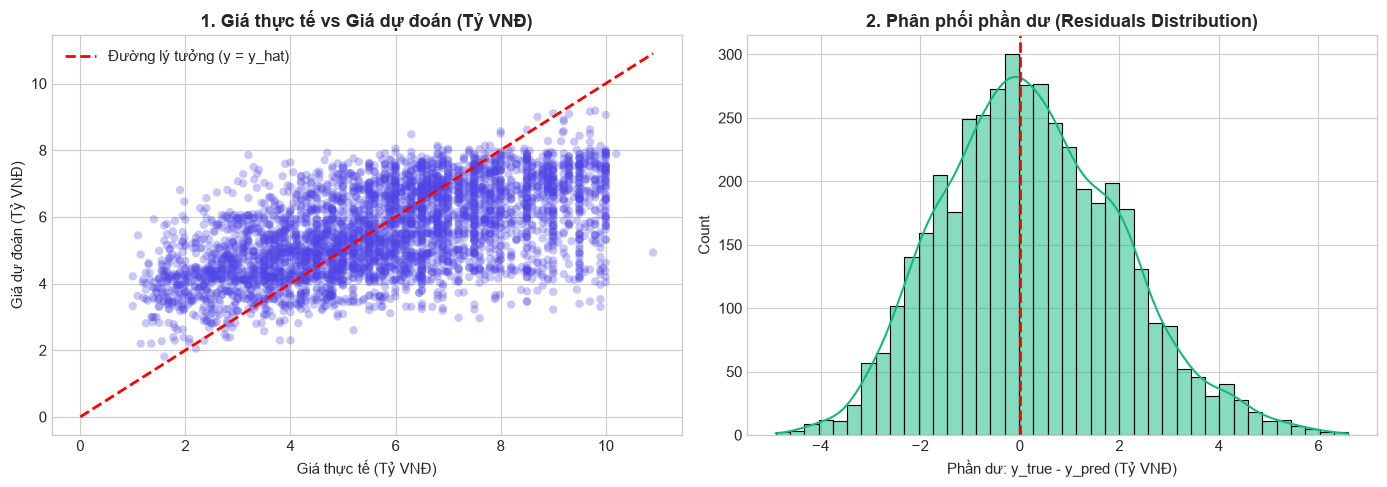

In [17]:
y_pred_best = np.expm1(best_xgb.predict(X_test))
residuals = y_true - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Giá trị thực tế vs Giá trị dự đoán
axes[0].scatter(y_true, y_pred_best, alpha=0.3, color='#4F46E5', edgecolors='none')
axes[0].plot([0, y_true.max()], [0, y_true.max()], 'r--', lw=2, label='Đường lý tưởng (y = y_hat)')
axes[0].set_title('1. Giá thực tế vs Giá dự đoán (Tỷ VNĐ)', fontweight='bold')
axes[0].set_xlabel('Giá thực tế (Tỷ VNĐ)')
axes[0].set_ylabel('Giá dự đoán (Tỷ VNĐ)')
axes[0].legend()

# 2. Phân phối phần dư (Residuals Plot)
sns.histplot(residuals, kde=True, ax=axes[1], color='#10B981', bins=40)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('2. Phân phối phần dư (Residuals Distribution)', fontweight='bold')
axes[1].set_xlabel('Phần dư: y_true - y_pred (Tỷ VNĐ)')

plt.tight_layout()
plt.show()

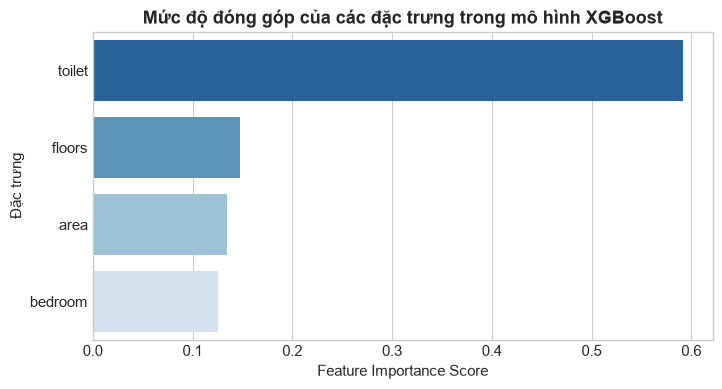

,Đặc trưng,Mức độ quan trọng (Importance)
2,toilet,0.591889
3,floors,0.147915
0,area,0.134958
1,bedroom,0.125238


In [18]:
importances = best_xgb.feature_importances_
feat_df = pd.DataFrame({
    'Đặc trưng': feature_cols,
    'Mức độ quan trọng (Importance)': importances
}).sort_values(by='Mức độ quan trọng (Importance)', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_df, x='Mức độ quan trọng (Importance)', y='Đặc trưng', palette='Blues_r', hue='Đặc trưng', legend=False)
plt.title('Mức độ đóng góp của các đặc trưng trong mô hình XGBoost', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.show()

display(feat_df)

In [19]:
import skl2onnx
import onnxmltools
from skl2onnx.common.data_types import FloatTensorType

# Định nghĩa kiểu tensor đầu vào cho ONNX Runtime
num_features = len(feature_cols)
initial_type = [('float_input', FloatTensorType([None, num_features]))]

# Xóa feature_names dạng string để onnxmltools nhận diện đúng các nhánh cây
best_xgb.get_booster().feature_names = None
onnx_model = onnxmltools.convert_xgboost(
    best_xgb, initial_types=initial_type, target_opset=12
)
print("-> Đã chuyển đổi thành công mô hình sang định dạng ONNX Runtime Engine!")

-> Đã chuyển đổi thành công mô hình sang định dạng ONNX Runtime Engine!


In [20]:
output_model_dir = '../model'
os.makedirs(output_model_dir, exist_ok=True)

# 1. Lưu file ONNX
onnx_file_path = os.path.join(output_model_dir, 'best_housing_model.onnx')
with open(onnx_file_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f" [OK] Đã lưu file mô hình ONNX tại: {os.path.abspath(onnx_file_path)}")

# 2. Lưu file Pickle dự phòng
pkl_file_path = os.path.join(output_model_dir, 'best_housing_model.pkl')
with open(pkl_file_path, 'wb') as f:
    joblib.dump(best_xgb, f)
print(f" [OK] Đã lưu file mô hình Pickle tại: {os.path.abspath(pkl_file_path)}")

 [OK] Đã lưu file mô hình ONNX tại: D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\house_price\model\best_housing_model.onnx
 [OK] Đã lưu file mô hình Pickle tại: D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\house_price\model\best_housing_model.pkl


In [21]:
import onnxruntime as ort
import time

# Khởi tạo phiên suy luận ONNX
session = ort.InferenceSession(onnx_file_path)
input_name = session.get_inputs()[0].name

# Mẫu nhà đất kiểm thử: Diện tích 85m², 3 phòng ngủ, 2 toilet, 3 tầng
sample_input = np.array([[85.0, 3.0, 2.0, 3.0]], dtype=np.float32)

# Đo lường thời gian suy luận (Latency benchmark)
t0 = time.time()
onnx_out = session.run(None, {input_name: sample_input})
pred_log_val = float(onnx_out[0].flatten()[0])
pred_price_val = float(np.expm1(pred_log_val))
latency_ms = (time.time() - t0) * 1000

print("=== KẾT QUẢ KIỂM THỬ SUY LUẬN ONNX THỰC TẾ ===")
print(f"- Input: Diện tích=85m², Phòng ngủ=3, Toilet=2, Số tầng=3")
print(f"- Giá ước tính dự đoán: {pred_price_val:.2f} Tỷ VNĐ")
print(f"- Đơn giá trung bình:   {(pred_price_val * 1000 / 85.0):.1f} Triệu VNĐ/m²")
print(f"- Thời gian suy luận:   {latency_ms:.3f} ms (Siêu tốc < 1ms)")
print("\n=> HỆ THỐNG SẴN SÀNG TRIỂN KHAI TRÊN FLASK REST API VÀ GIAO DIỆN WEB / MOBILE!")

=== KẾT QUẢ KIỂM THỬ SUY LUẬN ONNX THỰC TẾ ===
- Input: Diện tích=85m², Phòng ngủ=3, Toilet=2, Số tầng=3
- Giá ước tính dự đoán: 4.83 Tỷ VNĐ
- Đơn giá trung bình:   56.8 Triệu VNĐ/m²
- Thời gian suy luận:   0.315 ms (Siêu tốc < 1ms)

=> HỆ THỐNG SẴN SÀNG TRIỂN KHAI TRÊN FLASK REST API VÀ GIAO DIỆN WEB / MOBILE!
